# Character-Level Attention Maps

**Cropping strategy**: character-based, not pixel-based.  
Crop boundaries are derived from CTC peak positions (where the model predicts each character),  
ensuring the visible region is exactly the characters the model recognizes.

**Two views**:  
1. **Word-level** — one crop spanning the full decoded word, attention overlay per character  
2. **Character-level zoom** — uniform fixed-size window centered on each character

In [1]:
import sys, json
from pathlib import Path
from types import SimpleNamespace
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.ndimage import gaussian_filter, zoom as spzoom

ROOT = Path('.').resolve()
if ROOT.name == 'notebook': ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from models import HTRNet
from utils.preprocessing import load_image, preprocess

DEVICE = 'cpu'
IMG_H, IMG_W = 128, 1024
EXP = ROOT / 'saved_models' / 'experiments'
OUT = ROOT / 'outputs' / 'attention_maps'; OUT.mkdir(parents=True, exist_ok=True)
SAMPLES = ROOT / 'notebook' / 'sample_images'
charset = list(np.load(str(EXP / 'classes.npy'), allow_pickle=True))
print(f'{len(charset)} classes loaded')

79 classes loaded


In [2]:
# ── Utilities ─────────────────────────────────────────────────────

def load_model(run_id):
    cfg = json.load(open(EXP / run_id / 'config.json'))
    m = HTRNet(SimpleNamespace(**cfg['arch']), len(charset) + 1)
    m.load_state_dict(torch.load(str(EXP / run_id / 'model.pt'),
                                  map_location=DEVICE, weights_only=False), strict=False)
    return m.to(DEVICE).eval()

def prep(path):
    img = preprocess(load_image(str(path)), (IMG_H, IMG_W))
    return torch.from_numpy(img).unsqueeze(0).unsqueeze(0).float().to(DEVICE), img

def ctc_decode(logits):
    ids = logits[:, 0, :].softmax(-1).argmax(-1).cpu().numpy()
    out, prev = [], -1
    for t, idx in enumerate(ids):
        if idx != 0 and idx != prev:
            ci = idx - 1
            if 0 <= ci < len(charset):
                out.append((str(charset[ci]), t))
        prev = idx
    # strip leading/trailing spaces
    while out and out[0][0] == ' ':  out.pop(0)
    while out and out[-1][0] == ' ': out.pop()
    return ''.join(c for c, _ in out), out

def char_crop_bounds(char_peaks, Wp, pad_chars=1.5):
    """
    Character-based crop: boundaries come from CTC peak positions,
    not raw pixel ink. Adds `pad_chars` character-widths of margin.
    Returns (x0_px, x1_px) in image pixel coordinates.
    """
    scale = IMG_W / Wp  # px per patch (8.0)
    positions = [t for _, t in char_peaks]  # patch-space
    if len(positions) < 2:
        return 0, IMG_W
    avg_spacing = (positions[-1] - positions[0]) / (len(positions) - 1)
    pad = pad_chars * avg_spacing * scale
    x0 = max(0, int(positions[0] * scale - pad))
    x1 = min(IMG_W, int(positions[-1] * scale + pad))
    return x0, x1

def height_crop(img):
    """Tight vertical crop to ink rows (inverted: 0=white, high=ink)."""
    rmean = img.mean(1)
    rr = np.where(rmean > rmean.max() * 0.05)[0]
    if len(rr) == 0: return 0, img.shape[0]
    return max(0, rr[0] - 5), min(img.shape[0], rr[-1] + 5)

print('Utilities ready.')

Utilities ready.


In [3]:
# ── Load model & image ────────────────────────────────────────────
RUN = 'run_63'          # 8 registers, CER 6.26%
IMG = 'a01-038-12.png'  # GT: "talks."

model = load_model(RUN)
tensor, img_np = prep(SAMPLES / IMG)
R = model.backbone.num_registers

# Decode + explain
with torch.no_grad():
    logits, _, attn_maps, _, (Hp, Wp) = model.forward_explain(tensor)
text, char_peaks = ctc_decode(logits)

# Character-based crop bounds
x0, x1 = char_crop_bounds(char_peaks, Wp, pad_chars=1.5)
y0, y1 = height_crop(img_np)
img_c = img_np[y0:y1, x0:x1]

scale = IMG_W / Wp
print(f'Decoded: "{text}"  |  {len(char_peaks)} characters  |  R={R}')
print(f'Character crop: [{y0}:{y1}, {x0}:{x1}] = {img_c.shape}')
for ch, t in char_peaks:
    print(f'  "{ch}"  token={t}  pixel_x={t*scale:.0f}')

/home/hpc/iwi5/iwi5369h/HTR-Pipeline/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Decoded: "talks."  |  6 characters  |  R=8
Character crop: [0:128, 0:200] = (128, 200)
  "t"  token=3  pixel_x=24
  "a"  token=6  pixel_x=48
  "l"  token=9  pixel_x=72
  "k"  token=12  pixel_x=96
  "s"  token=16  pixel_x=128
  "."  token=20  pixel_x=160


In [4]:
# ── Gradient Saliency per character ───────────────────────────────
#
# saliency(c) = | ∂ logit[t_c, class_c] / ∂ x |   (Gaussian smoothed)
# Crops to the same character-based window for uniform framing.

sal_maps = []
for ch, t in char_peaks:
    inp = tensor.clone().requires_grad_(True)
    model.zero_grad()
    out = model(inp)
    out[t, 0, charset.index(ch) + 1].backward()
    g = inp.grad[0, 0].abs().cpu().numpy()
    g = gaussian_filter(g, sigma=2)[y0:y1, x0:x1]
    gmin, gmax = g.min(), g.max()
    sal_maps.append((g - gmin) / (gmax - gmin) if gmax > gmin else g * 0)
    print(f'  "{ch}" done')

print(f'{len(sal_maps)} saliency maps computed.')

  "t" done
  "a" done
  "l" done
  "k" done
  "s" done
  "." done
6 saliency maps computed.


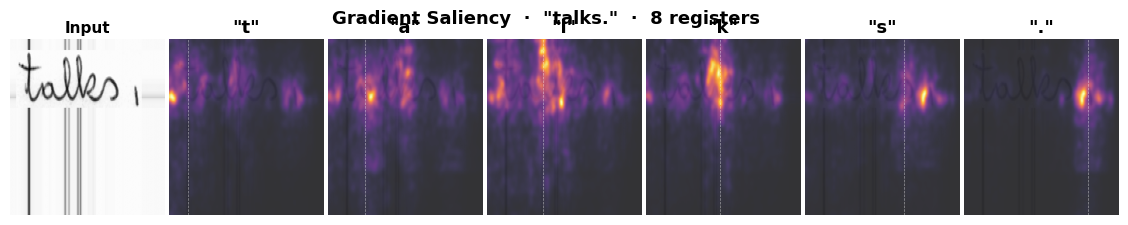

Saved attention_word_saliency.png


In [5]:
# ── Figure 1: Word-level view — Input + per-character saliency ───
#
# All panels share the same character-based crop.
# Layout: [Input] ["t"] ["a"] ["l"] ["k"] ["s"] ["."]

n = len(char_peaks)
ncols = n + 1
pw = 2.0  # panel width in inches
ar = img_c.shape[0] / img_c.shape[1]
ph = max(pw * ar, 0.8)

fig, axes = plt.subplots(1, ncols, figsize=(pw * ncols + 0.3, ph + 1.0))

# Input panel
axes[0].imshow(img_c, cmap='gray_r', aspect='auto')
axes[0].set_title('Input', fontsize=11, fontweight='bold', pad=5)

# Per-character saliency panels
for i, ((ch, t), sal) in enumerate(zip(char_peaks, sal_maps)):
    ax = axes[i + 1]
    ax.imshow(img_c, cmap='gray_r', aspect='auto', alpha=0.2)
    ax.imshow(sal, cmap='inferno', aspect='auto', alpha=0.8, vmin=0, vmax=1)
    # Mark character center
    cx = t * scale - x0
    ax.axvline(cx, color='white', lw=0.5, ls='--', alpha=0.5)
    ax.set_title(f'"{ch}"', fontsize=13, fontweight='bold', pad=5)

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_visible(False)

fig.suptitle(f'Gradient Saliency  ·  "{text}"  ·  {R} registers',
             fontsize=13, fontweight='bold', y=1.01)
plt.subplots_adjust(wspace=0.03)
fig.savefig(str(OUT / 'attention_word_saliency.png'), dpi=200, bbox_inches='tight')
fig.savefig(str(OUT / 'attention_word_saliency.pdf'), bbox_inches='tight')
plt.show(); plt.close(fig)
print('Saved attention_word_saliency.png')

/home/hpc/iwi5/iwi5369h/HTR-Pipeline/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Uniform cell: 54 × 128 px  |  half_w=27px  |  mean_spacing=27.2px


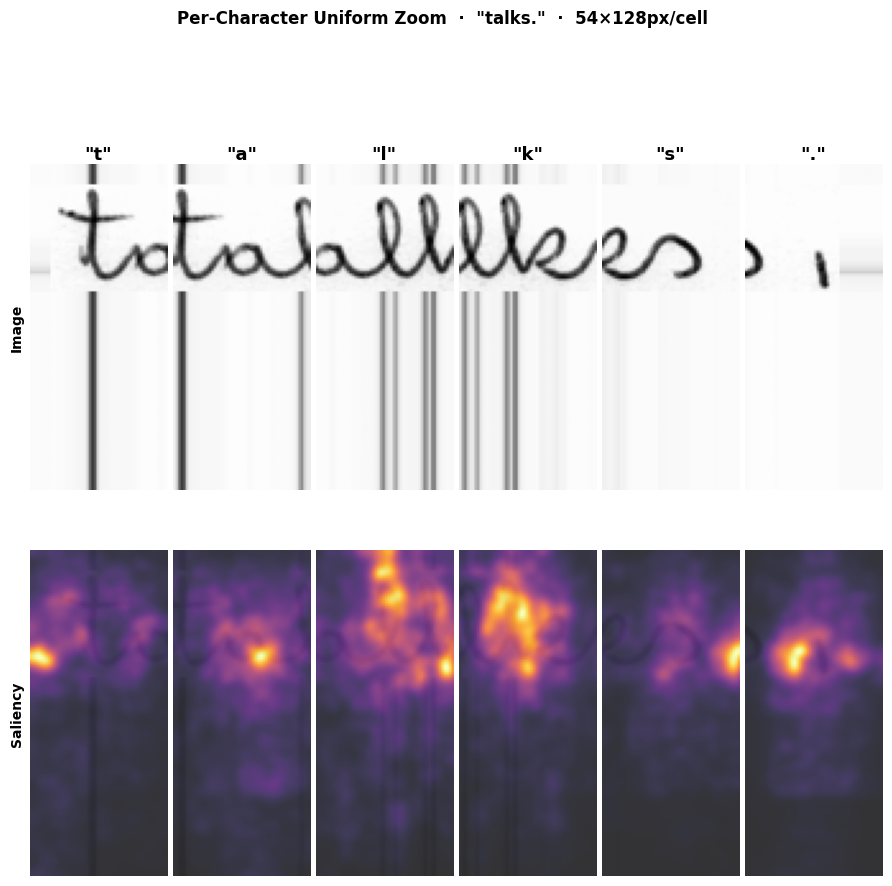

Saved attention_char_zoom.png


In [10]:
# ── Figure 2: Per-character zoom crops — uniform windows ──────────
#
# Each column = one character.  Each cell = identical-size window
# centered on that character's CTC peak. Tight context ≈ 1 char-width
# on each side so panels are directly comparable.

# Reload model if needed (may have been released by a prior cell)
try:
    model
except NameError:
    model = load_model(RUN)

positions_px = [t * scale for _, t in char_peaks]
mean_spacing = (positions_px[-1] - positions_px[0]) / (len(positions_px) - 1)
half_w = max(int(1.0 * mean_spacing), 16)   # ±1 char-width: tight but with context
crop_w = 2 * half_w
crop_h = y1 - y0
print(f'Uniform cell: {crop_w} × {crop_h} px  |  half_w={half_w}px  |  mean_spacing={mean_spacing:.1f}px')

# Full-image saliency (no pre-crop — we window-crop below)
full_sal = []
for ch, t in char_peaks:
    inp = tensor.clone().requires_grad_(True)
    model.zero_grad()
    out = model(inp)
    out[t, 0, charset.index(ch) + 1].backward()
    g = inp.grad[0, 0].abs().cpu().numpy()
    full_sal.append(gaussian_filter(g, sigma=2))

fig, axes = plt.subplots(2, n, figsize=(1.8 * n + 0.2, 2 * 1.8 * crop_h / crop_w + 1.2))

for i, ((ch, t), sal) in enumerate(zip(char_peaks, full_sal)):
    cx = int(t * scale)
    lx = max(0, cx - half_w)
    rx = lx + crop_w
    if rx > IMG_W: rx = IMG_W; lx = rx - crop_w
    lx = max(0, lx)

    img_win = img_np[y0:y1, lx:rx]
    sal_win = sal[y0:y1, lx:rx]
    if img_win.shape[1] < crop_w:
        p = crop_w - img_win.shape[1]
        img_win = np.pad(img_win, ((0,0),(0,p)), constant_values=0)
        sal_win = np.pad(sal_win, ((0,0),(0,p)), constant_values=0)

    smin, smax = sal_win.min(), sal_win.max()
    sal_norm = (sal_win - smin) / (smax - smin) if smax > smin else sal_win * 0

    axes[0, i].imshow(img_win, cmap='gray_r', aspect='equal')
    axes[0, i].set_title(f'"{ch}"', fontsize=13, fontweight='bold', pad=4)

    axes[1, i].imshow(img_win, cmap='gray_r', aspect='equal', alpha=0.2)
    axes[1, i].imshow(sal_norm, cmap='inferno', aspect='equal', alpha=0.8, vmin=0, vmax=1)

for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_visible(False)

axes[0, 0].set_ylabel('Image', fontsize=10, fontweight='bold')
axes[1, 0].set_ylabel('Saliency', fontsize=10, fontweight='bold')

fig.suptitle(f'Per-Character Uniform Zoom  ·  "{text}"  ·  {crop_w}×{crop_h}px/cell',
             fontsize=12, fontweight='bold', y=1.02)
plt.subplots_adjust(wspace=0.04, hspace=0.06)
fig.savefig(str(OUT / 'attention_char_zoom.png'), dpi=200, bbox_inches='tight')
fig.savefig(str(OUT / 'attention_char_zoom.pdf'), bbox_inches='tight')
plt.show(); plt.close(fig)
print('Saved attention_char_zoom.png')


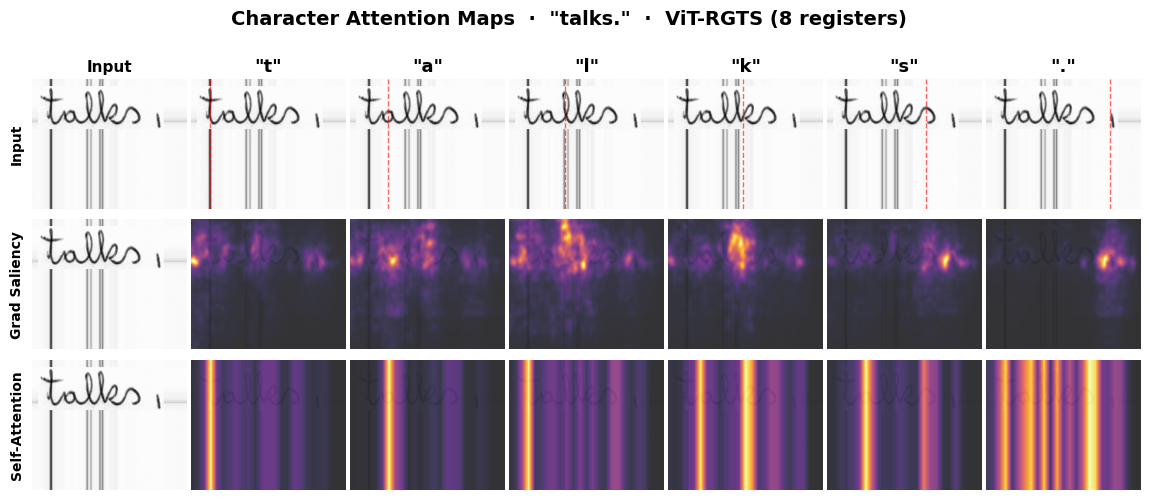

Saved attention_combined.png


In [7]:
# ── Figure 3: Combined — Full word + self-attention + saliency ────
#
# Row 0: Input (word crop, repeated)
# Row 1: Gradient saliency overlay
# Row 2: Self-attention overlay
#
# Self-attention: last layer, head-averaged, at each character's CTC peak.

attn_last = attn_maps[-1][0].mean(0).numpy()  # [S, S]
pl = max(0, int(x0 / scale))
pr = min(Wp, int(np.ceil(x1 / scale)))

attn_cropped = []
for ch, t in char_peaks:
    row = attn_last[R + t, R:][pl:pr]
    rmin, rmax = row.min(), row.max()
    row_n = (row - rmin) / (rmax - rmin) if rmax > rmin else row * 0
    # Upsample to cropped image width
    a_up = spzoom(row_n, img_c.shape[1] / len(row_n), order=1)[:img_c.shape[1]]
    attn_cropped.append(np.tile(a_up, (img_c.shape[0], 1)))

fig, axes = plt.subplots(3, ncols, figsize=(pw * ncols + 0.3, 3 * ph + 1.5))

row_labels = ['Input', 'Grad Saliency', 'Self-Attention']
for row in range(3):
    # Column 0: input image (all rows)
    axes[row, 0].imshow(img_c, cmap='gray_r', aspect='auto')
    axes[row, 0].set_ylabel(row_labels[row], fontsize=10, fontweight='bold', labelpad=6)
    if row == 0:
        axes[row, 0].set_title('Input', fontsize=11, fontweight='bold', pad=5)

    for i, (ch, t) in enumerate(char_peaks):
        ax = axes[row, i + 1]
        if row == 0:
            ax.imshow(img_c, cmap='gray_r', aspect='auto')
            # Mark character center
            cx = t * scale - x0
            ax.axvline(cx, color='red', lw=1.0, ls='--', alpha=0.6)
            ax.set_title(f'"{ch}"', fontsize=13, fontweight='bold', pad=5)
        elif row == 1:
            ax.imshow(img_c, cmap='gray_r', aspect='auto', alpha=0.2)
            ax.imshow(sal_maps[i], cmap='inferno', aspect='auto', alpha=0.8, vmin=0, vmax=1)
        elif row == 2:
            ax.imshow(img_c, cmap='gray_r', aspect='auto', alpha=0.2)
            ax.imshow(attn_cropped[i], cmap='inferno', aspect='auto', alpha=0.8, vmin=0, vmax=1)

for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_visible(False)

fig.suptitle(f'Character Attention Maps  ·  "{text}"  ·  ViT-RGTS ({R} registers)',
             fontsize=14, fontweight='bold', y=1.01)
plt.subplots_adjust(wspace=0.03, hspace=0.08)
fig.savefig(str(OUT / 'attention_combined.png'), dpi=200, bbox_inches='tight')
fig.savefig(str(OUT / 'attention_combined.pdf'), bbox_inches='tight')
plt.show(); plt.close(fig)
print('Saved attention_combined.png')

/home/hpc/iwi5/iwi5369h/HTR-Pipeline/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


   0 reg → "talks."
   4 reg → "talks."
   8 reg → "talks."
  16 reg → "talks."


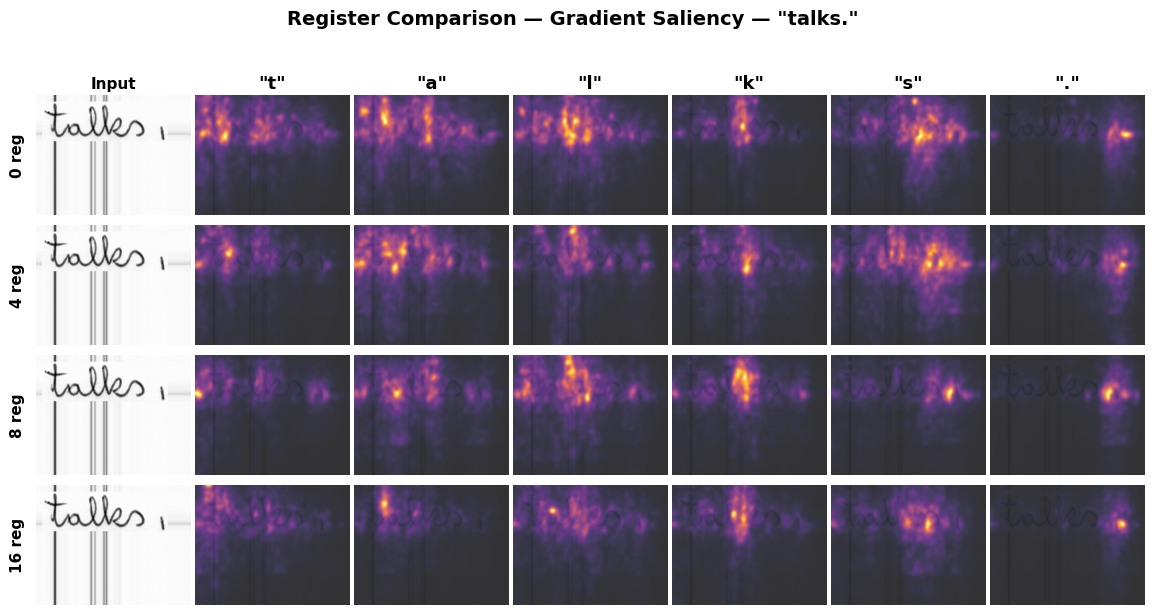

Saved attention_register_comparison.png


: 

In [ ]:
# ── Figure 4: Register comparison — 0/4/8/16 registers ───────────
#
# Same character-based crop, gradient saliency, different register counts.
# Rows = register configs, Columns = Input + characters.

del model  # free memory
RUNS = {0: 'run_76', 4: 'run_84', 8: 'run_63', 16: 'run_71'}
reg_keys = sorted(RUNS.keys())
nrows = len(reg_keys)

fig, axes = plt.subplots(nrows, ncols, figsize=(pw * ncols + 0.3, ph * nrows + 1.5))

for row, nr in enumerate(reg_keys):
    mdl = load_model(RUNS[nr])
    with torch.no_grad():
        lg = mdl(tensor)
    txt, peaks = ctc_decode(lg)

    # Input column
    axes[row, 0].imshow(img_c, cmap='gray_r', aspect='auto')
    axes[row, 0].set_ylabel(f'{nr} reg', fontsize=11, fontweight='bold', labelpad=8)
    if row == 0:
        axes[row, 0].set_title('Input', fontsize=11, fontweight='bold', pad=5)

    # Per-character saliency
    for ci in range(n):
        ax = axes[row, ci + 1]
        if ci < len(peaks):
            ch_i, t_i = peaks[ci]
            inp = tensor.clone().requires_grad_(True)
            mdl.zero_grad()
            out = mdl(inp)
            out[t_i, 0, charset.index(ch_i) + 1].backward()
            g = inp.grad[0, 0].abs().cpu().numpy()
            g = gaussian_filter(g, sigma=2)[y0:y1, x0:x1]
            gmin, gmax = g.min(), g.max()
            s = (g - gmin) / (gmax - gmin) if gmax > gmin else g * 0
            ax.imshow(img_c, cmap='gray_r', aspect='auto', alpha=0.2)
            ax.imshow(s, cmap='inferno', aspect='auto', alpha=0.8, vmin=0, vmax=1)
        else:
            ax.imshow(np.zeros_like(img_c), cmap='gray', aspect='auto')
        if row == 0 and ci < len(char_peaks):
            ax.set_title(f'"{char_peaks[ci][0]}"', fontsize=13, fontweight='bold', pad=5)

    for ax in axes[row]:
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values(): sp.set_visible(False)

    del mdl
    print(f'  {nr:>2} reg → "{txt}"')

fig.suptitle(f'Register Comparison — Gradient Saliency — "{text}"',
             fontsize=14, fontweight='bold', y=1.01)
plt.subplots_adjust(wspace=0.03, hspace=0.08)
fig.savefig(str(OUT / 'attention_register_comparison.png'), dpi=200, bbox_inches='tight')
fig.savefig(str(OUT / 'attention_register_comparison.pdf'), bbox_inches='tight')
plt.show(); plt.close(fig)
print('Saved attention_register_comparison.png')